In [1]:
# Importing Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Model Selection & Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, accuracy_score, precision_recall_curve

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

In [2]:
# loading the dataset
df = pd.read_csv("C:\\Users\\vinit\\Downloads\\ML Module\\Projects\\Credict Risk & Loan Default Prediction\\home-credit-default-risk\\application_train.csv")
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Shape of the dataset
df.shape

(307511, 122)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [5]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# Checking missing percentage  
missing_percent = df.isnull().mean() * 100
missing_percent.sort_values(ascending=False).head(10)

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
dtype: float64

In [8]:
df['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [9]:
# Percentage Distribution
df['TARGET'].value_counts(normalize=True) * 100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

##### Initial Observations
- The dataset contains 307511 rows and 122 columns. 
- The target variable is TARGET, where 0 indicates no default and 1 indicates default.
- Some columns have a high percentage of missing values, e.g., COMMONAREA_MEDI, LIVINGAPARTMENTS_MEDI (~68–70%), which may need to be dropped or
  imputed.
- There is no duplicate rows in the dataset.
- The dataset contains a mix of numerical and categorical features, requiring separate preprocessing pipelines.
- The target variable is imbalanced, with more non-defaulters (0) than defaulters (1).
- This class imbalance can be handled during model training using techniques such as class weighting, resampling, or choosing metrics like ROC-AUC
  or precision-recall curves.

**Exploratory Data Analysis(EDA)**

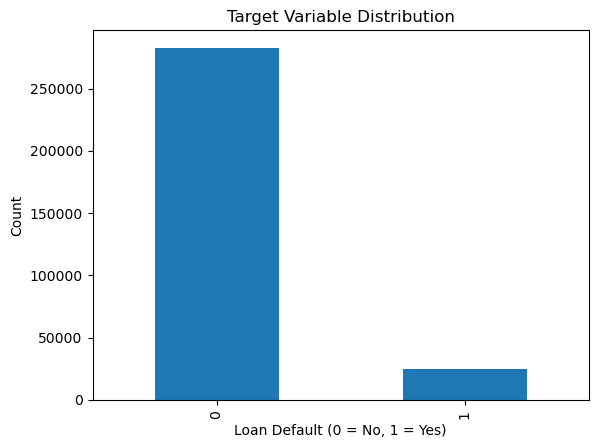

In [10]:
# Target Variable Distribution
df['TARGET'].value_counts().plot(kind='bar')
plt.title("Target Variable Distribution")
plt.xlabel("Loan Default (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

**Observation:** 
- The dataset is imbalanced: most applicants did not default.
- This imbalance can bias models toward predicting non-default.
- This confirms the need for class balancing techniques like SMOTE or class weights.

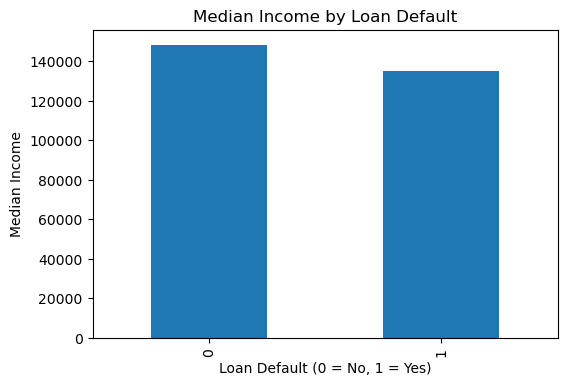

In [11]:
#Income vs Loan Default
plt.figure(figsize=(6,4))
df.groupby('TARGET')['AMT_INCOME_TOTAL'].median().plot(kind='bar')
plt.title("Median Income by Loan Default")
plt.xlabel("Loan Default (0 = No, 1 = Yes)")
plt.ylabel("Median Income")
plt.show()

**Observation:**  
- Median income of applicants who defaulted (TARGET=1) is lower than those who did not default (TARGET=0).  
- This indicates that **income is an important predictor** of credit risk.

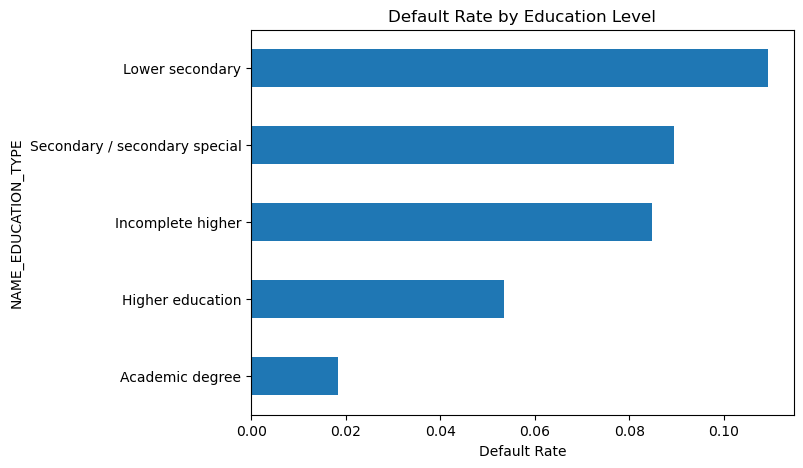

In [12]:
# Education level vs Default
edu_default = df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values()
edu_default.plot(kind='barh', figsize=(7,5))
plt.title("Default Rate by Education Level")
plt.xlabel("Default Rate")
plt.show()

**Observation:**  
- Applicants with lower education levels (e.g., Secondary / Lower) tend to have higher default rates.  
- Higher education levels (e.g., Higher Education or Academic Degree) are associated with lower default risk.  
- Education level is therefore a predictive categorical feature for credit risk.

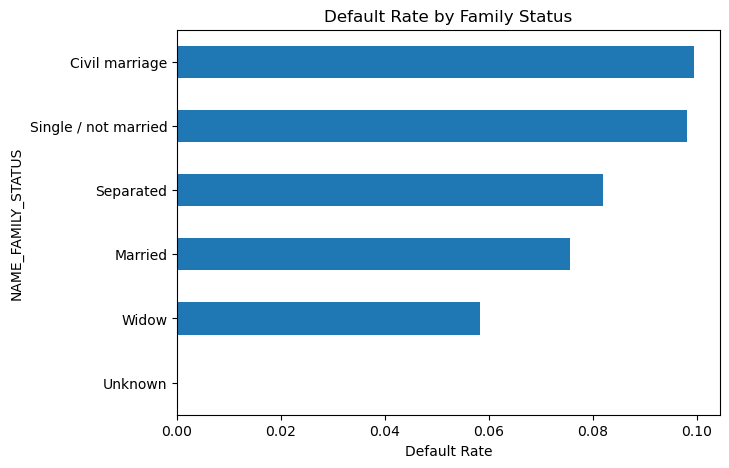

In [13]:
# Family status vs Default
family_default = df.groupby('NAME_FAMILY_STATUS')['TARGET'].mean().sort_values()

family_default.plot(kind='barh', figsize=(7,5))
plt.title("Default Rate by Family Status")
plt.xlabel("Default Rate")
plt.show()

**Observation:**  
- Applicants who are single or divorced tend to have higher default rates.  
- Married applicants or those living with a partner show lower default risk.  
- Family status can be considered a predictive categorical feature for credit risk modeling.

In [14]:
# Feature Engineering
df['EMPLOYMENT_YEARS'] = -df['DAYS_EMPLOYED'] / 365  # Convert DAYS_EMPLOYED to years of employment

# Convert DAYS_BIRTH to age in years
df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365  

# Calculate debt-to-income ratio
df['CREDIT_TO_INCOME'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

# Calculate annuity-to-income ratio
df['ANNUITY_TO_INCOME'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

# Handle infinite and missing values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [15]:
# Selecting best features
features = [
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_INCOME_TOTAL",
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "OCCUPATION_TYPE",
    "CREDIT_TO_INCOME",
    "ANNUITY_TO_INCOME"
]

##### 🔍 Feature Selection

To improve model performance and simplify deployment, a subset of the most relevant features was selected based on domain knowledge and their predictive importance.

The selected features include:
- Financial attributes such as income, credit amount, and annuity
- Derived ratios like credit-to-income and annuity-to-income
- Demographic factors such as age and employment years
- Occupation type, representing the applicant’s job category and financial stability indicator

This step helps reduce model complexity, avoid overfitting, and ensure that only meaningful features are used for training and prediction.

In [16]:
# Separating target & features
X = df[features]
y = df['TARGET']

In [17]:
# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)

(246008, 8) (61503, 8)


In [18]:
# Numeric and categorical columns
num_cols = X_train.select_dtypes(exclude='object').columns.tolist()
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

In [19]:
# Preprocessing Pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])

##### Data Preprocessing Pipeline
Built a ColumnTransformer pipeline for:
- Missing value imputation
- Scaling numerical features
- Encoding categorical features

**Model Building**

In [20]:
# Logistic Regression 
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
])

model_lr.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
# Random Forest
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        n_jobs=-1,
        class_weight='balanced',
        random_state=42
    ))
])

model_rf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [23]:
# XGBoost pipeline
pos = len(y_train[y_train == 1])
neg = len(y_train[y_train == 0])

scale_pos_weight = neg / pos if pos != 0 else 1

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])
xgb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**Model Evaluation**

In [24]:
# Predictions
y_pred_lr = model_lr.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

In [25]:
# ROC-AUC 
y_prob_lr = model_lr.predict_proba(X_test)[:,1]
y_prob_rf = model_rf.predict_proba(X_test)[:,1]
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

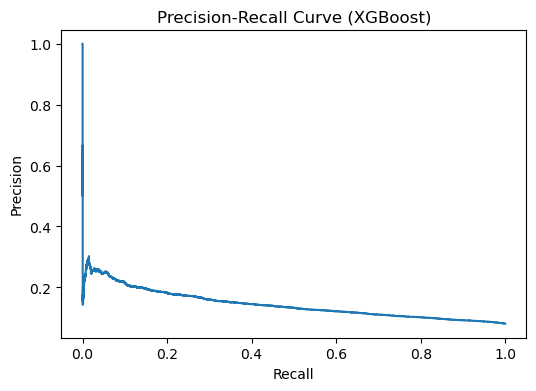

In [26]:
# Get precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)

# Plot
plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGBoost)")
plt.show()

In [27]:
# Find best threshold
target_recall = 0.70

best_threshold = 0.5
best_precision = 0

for i in range(len(thresholds)):
    if recall[i] >= target_recall:
        if precision[i] > best_precision:
            best_precision = precision[i]
            best_threshold = thresholds[i]

print("Best Threshold:", best_threshold)
y_pred = (y_prob_xgb >= best_threshold).astype(int)

Best Threshold: 0.45028076


##### Threshold Optimization
We tuned the classification threshold using Precision-Recall curve to achieve 70% recall for defaulters.

In [28]:
print("Logistic Regression")
print(accuracy_score(y_test, y_pred_lr))
print(roc_auc_score(y_test, y_prob_lr))

print("Random Forest")
print(accuracy_score(y_test, y_pred_rf))
print(roc_auc_score(y_test, y_prob_rf))

print("XGBoost")
print(accuracy_score(y_test, y_pred))
print(roc_auc_score(y_test, y_prob_xgb))

Logistic Regression
0.5768011316521146
0.6093759646258465
Random Forest
0.6361315708176837
0.6358102885610145
XGBoost
0.5216330910687283
0.6513429248291045


In [29]:
# Classification Report
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

print("XGBoost")
print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.94      0.58      0.71     56538
           1       0.11      0.59      0.18      4965

    accuracy                           0.58     61503
   macro avg       0.52      0.58      0.45     61503
weighted avg       0.87      0.58      0.67     61503

Random Forest
              precision    recall  f1-score   support

           0       0.94      0.64      0.76     56538
           1       0.12      0.55      0.20      4965

    accuracy                           0.64     61503
   macro avg       0.53      0.60      0.48     61503
weighted avg       0.88      0.64      0.72     61503

XGBoost
              precision    recall  f1-score   support

           0       0.95      0.51      0.66     56538
           1       0.11      0.70      0.19      4965

    accuracy                           0.52     61503
   macro avg       0.53      0.60      0.43     61503
weighted avg       0.88      0.5

In [30]:
# Confusion Matrix of XGBoost
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:

[[28606 27932]
 [ 1489  3476]]


In [31]:
# Cross-Validation
cv_auc = cross_val_score(
    xgb_pipeline,
    X_train,
    y_train,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

print("Cross-Validation ROC-AUC scores:", cv_auc)
print("Mean CV ROC-AUC:", cv_auc.mean())

Cross-Validation ROC-AUC scores: [0.65462315 0.64451232 0.64401607 0.65225357 0.64756012]
Mean CV ROC-AUC: 0.648593046928756


Among the evaluated models, XGBoost demonstrated the best performance, achieving the highest ROC-AUC score along with strong recall for the defaulter class.

To align the model with business objectives, the classification threshold was optimized using the precision-recall curve to achieve a target recall of 0.70 for defaulters. This ensures that the model prioritizes identifying high-risk applicants while effectively reducing false negatives.

Since minimizing loan defaults is a key objective in credit risk modeling, XGBoost was selected as the final model. Although this threshold adjustment leads to a trade-off with precision, it is acceptable in real-world banking scenarios where identifying potential defaulters is more critical than incorrectly rejecting some low-risk applicants.

In [32]:
# Save the Model 
import pickle

with open("credit_risk_model.pkl", "wb") as f:
    pickle.dump(xgb_pipeline, f)

print("Model saved successfully!")

Model saved successfully!


**Conclusion**

**Project Overview**

This project focused on building an end-to-end Credit Risk Prediction system to identify loan applicants likely to default. The goal was to simulate a real-world banking use case using data preprocessing, feature engineering, model building, evaluation, and deployment.

**Data Understanding and Preprocessing**
- The dataset contained numerical and categorical features with missing values and class imbalance.
- Missing values were handled using median (numerical) and most frequent (categorical) imputation.
- Feature scaling and one-hot encoding were applied using a preprocessing pipeline.
- Basic feature engineering was performed to create financial ratio-based features.
- Exploratory Data Analysis was used to understand data distribution and target imbalance.

**Model Development**

Three models were trained and compared:
- Logistic Regression (baseline model)
- Random Forest (non-linear relationships)
- XGBoost (best performing model)

XGBoost performed the best in terms of ROC-AUC and recall for the defaulter class.

**Model Evaluation and Optimization**
- Model performance was evaluated using ROC-AUC, precision, recall, F1-score, and confusion matrix.
- The dataset was highly imbalanced, so recall for defaulters was prioritized.
- The classification threshold was tuned using the precision-recall curve to achieve a recall of 0.70 for defaulters
- This ensured more high-risk applicants were correctly identified, reducing false negatives.

XGBoost achieved the best overall performance and was selected as the final model.

**Deployment**
- The final trained pipeline was saved using pickle/joblib and deployed using Streamlit.
- The application allows users to input applicant details and receive real-time:
   - Default probability
   - Risk prediction (High/Low risk)

**Business Impact**

This system helps financial institutions make better lending decisions by identifying high-risk applicants early, reducing loan defaults, and improving overall risk management through data-driven decision-making.